In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [ ]:
import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

In [ ]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
# Mean Glucose Levels by Age Group

In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[20,30,40,50,60,80],
    labels=["20-30","30-40","40-50","50-60","60+"]
)

In [ ]:
mean_glucose["Mean Glucose Level"] = mean_glucose["Mean Glucose Level"].round(2)

print(mean_glucose)

  Age Group  Mean Glucose Level
0     20-30              115.05
1     30-40              126.95
2     40-50              125.96
3     50-60              141.15
4       60+              136.85


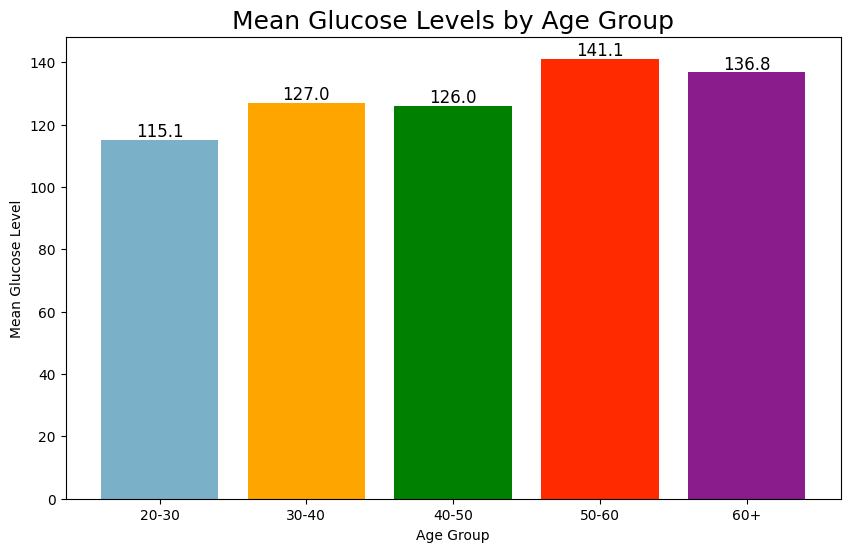

In [ ]:
# Mean glucose values 

age_groups = ["20-30", "30-40", "40-50", "50-60", "60+"]
mean_glucose = [115.1, 127.0, 126.0, 141.1, 136.8]

ccolors = ["skyblue", "orange", "green", "red", "purple"]

plt.figure(figsize=(10,6))
bars = plt.bar(age_groups, mean_glucose, color=colors)

# Value labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 1, f"{y:.1f}", 
             ha='center', fontsize=12)

plt.title("Mean Glucose Levels by Age Group", fontsize=18)
plt.xlabel("Age Group")
plt.ylabel("Mean Glucose Level")

plt.show()

In [ ]:
# ANOVA: Compare BMI Across Outcome Groups

In [ ]:
# Separate BMI values for diabetic and non-diabetic patients

bmi_diabetes = df[df["Outcome"] == 1]["BMI"]
bmi_no_diabetes = df[df["Outcome"] == 0]["BMI"]

In [ ]:
#Perform ANOVA test to compare BMI between groups

from scipy import stats

anova_result = stats.f_oneway(bmi_diabetes, bmi_no_diabetes)

print("ANOVA Result:", anova_result)

ANOVA Result: F_onewayResult(statistic=np.float64(82.56242947356479), pvalue=np.float64(8.595300884275688e-19))


In [ ]:
#Calculate mean BMI for each outcome group
bmi_mean = df.groupby("Outcome")["BMI"].mean().reset_index()
bmi_mean.columns = ["Outcome", "Mean BMI"]

bmi_mean

,Outcome,Mean BMI
0,0,30.888434
1,1,35.384757


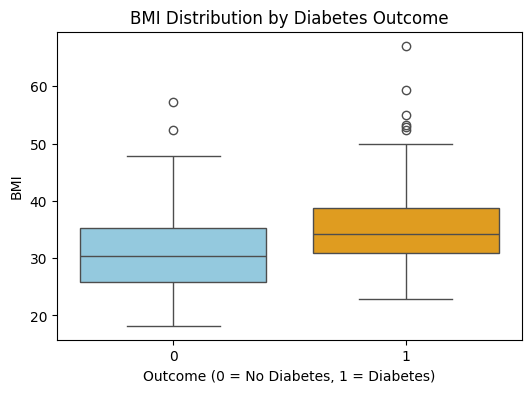

In [ ]:
# Visualization: BMI Distribution by Diabetes Outcome


plt.figure(figsize=(6,4))

sns.boxplot(
    x="Outcome",
    y="BMI",
    hue="Outcome",
    data=df,
    palette=["skyblue","orange"],
    legend=False
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.show()

In [ ]:
# ML: Regression to Predict Disease Progression

In [ ]:
#Define features and target variable

X = df.drop(["Outcome","AgeGroup"], axis=1)
y = df["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33


In [ ]:
# Split Dataset into Training and Testing Sets

In [ ]:
split_summary = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

split_summary

,Dataset,Rows,Columns
0,Training Data,614,8
1,Testing Data,154,8


In [ ]:
# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Make Predictions

In [ ]:
# # Create table for predicted values

results = pd.DataFrame({
    "Actual Outcome": y_test.values[:10],
    "Predicted Outcome": y_pred[:10]
})

results

,Actual Outcome,Predicted Outcome
0,0,0.325990
1,0,0.216661
2,0,0.133885
3,0,0.208986
4,0,0.480740
5,0,0.449756
6,0,-0.218889
7,0,0.401950
8,0,0.553379
9,0,0.695313


In [ ]:
# Step 6: Evaluate Model Performance

from sklearn.metrics import mean_squared_error, r2_score

metrics = pd.DataFrame({
    "Metric": ["Mean Squared Error", "R² Score"],
    "Value": [
        mean_squared_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ]
})

metrics

,Metric,Value
0,Mean Squared Error,0.164324
1,R² Score,0.284277


In [ ]:
# Visualization: Actual vs Predicted Diabetes Outcomes

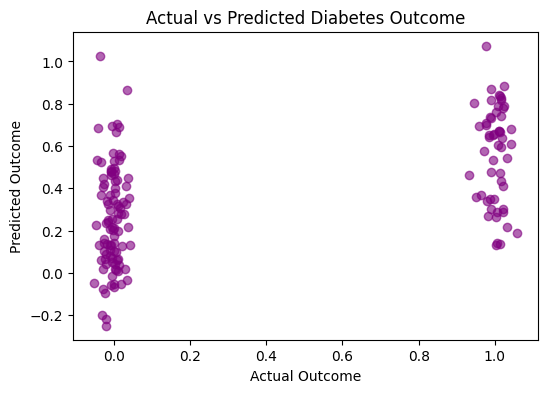

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(y_test + np.random.normal(0,0.02,len(y_test)),
            y_pred,
            color="purple",
            alpha=0.6)

plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome")
plt.title("Actual vs Predicted Diabetes Outcome")

plt.show()

In [ ]:
# Visualization: Pairplots of Health Indicators

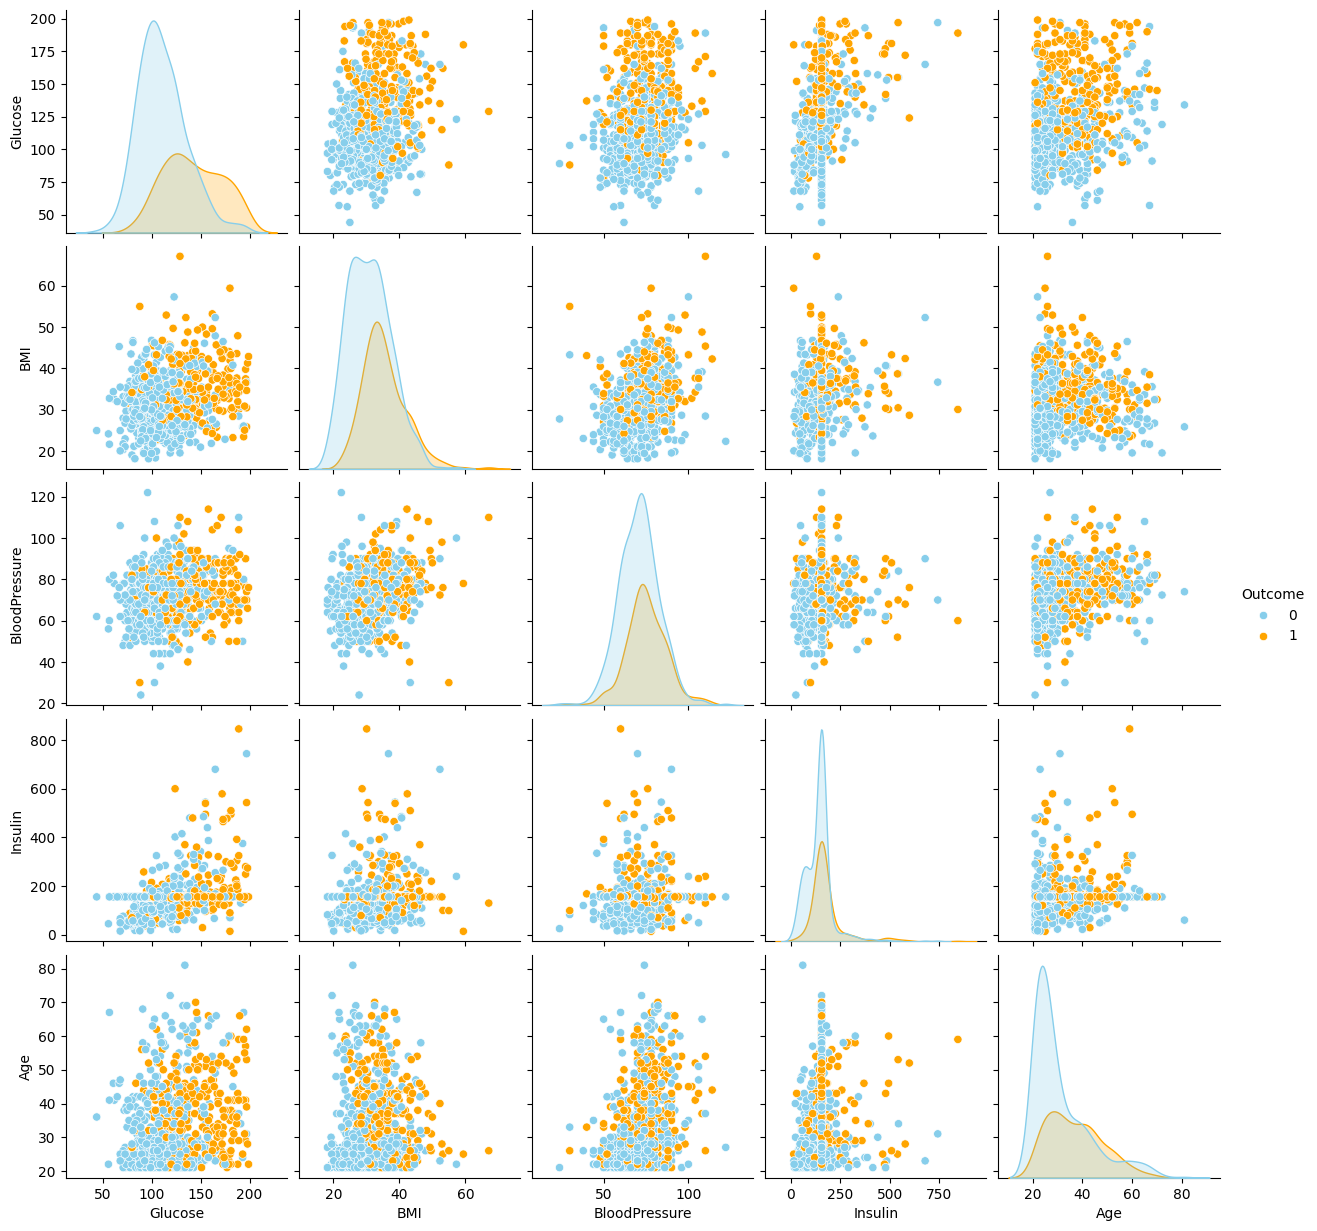

In [ ]:
# Visualization: Pairplots of Health Indicators

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['Glucose','BMI','BloodPressure','Insulin','Age','Outcome']],
    hue='Outcome',
    palette=['skyblue','orange']
)

plt.show()

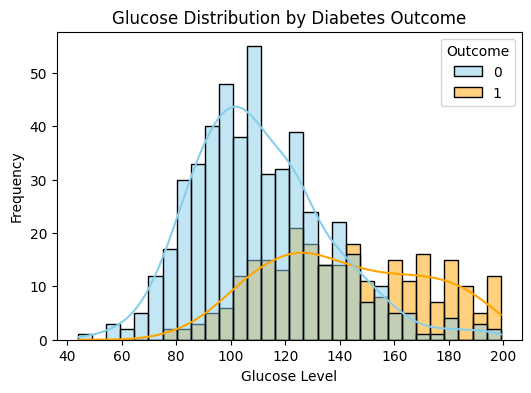

In [ ]:
# Visualization: Glucose Distribution by Diabetes Outcome

plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="Glucose",
    hue="Outcome",
    bins=30,
    palette=["skyblue","orange"],
    kde=True
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

plt.show()

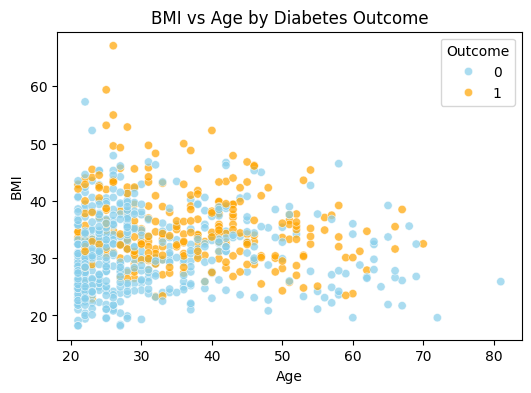

In [54]:
# Visualization: BMI vs Age by Diabetes Outcome

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Age",
    y="BMI",
    hue="Outcome",
    palette=["skyblue","orange"],
    alpha=0.7
)

plt.title("BMI vs Age by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.show()